In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

In [ ]:
#leer la matriz de similitud del csv del lab 2 y crear la de disimilitud
matriz_similitud = pd.read_csv('matriz_similitud_wl3.csv', index_col=False)
matriz_similitud = matriz_similitud.to_numpy()
D = 1 - matriz_similitud


In [ ]:
import networkx as nx
from sklearn.manifold import MDS

def analizar_disimilitud(matrix):

    n = matrix.shape[0]
    #2. Crear gráfica completa ponderada ---
    G = nx.Graph()
    for i in range(n):
        for j in range(i + 1, n):
            G.add_edge(i, j, weight=D[i, j])


    #3. Obtener el Árbol de Expansión Mínima (MST) ---
    MST = nx.minimum_spanning_tree(G, weight='weight')

    # Extraemos los pesos de las aristas
    weights = np.array([d['weight'] for _, _, d in MST.edges(data=True)])
    umbral = np.median(weights) #Definimos el umbral como la Mediana

    # Eliminamos aristas "inconsistentes" (peso mayor al umbral)
    edges_to_remove = [(u, v) for u, v, d in MST.edges(data=True) if d['weight'] > umbral]
    MST.remove_edges_from(edges_to_remove)

    #4. Aplicar MDS para proyectar en R² ---
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    coords = mds.fit_transform(D)

    #5. Visualización: puntos + aristas del MST ---
    plt.figure(figsize=(10, 10))
    plt.scatter(coords[:, 0], coords[:, 1], color='pink', s=150, edgecolor='black', label='Instancias')

    # Dibujar las aristas del MST (usando las posiciones proyectadas)
    for (i, j) in MST.edges():
        x_coords = [coords[i, 0], coords[j, 0]]
        y_coords = [coords[i, 1], coords[j, 1]]
        plt.plot(x_coords, y_coords, color='black', linewidth=1, alpha=0.75)

    #Representar MDS con
    plt.title("Proyección 2D con Árbol de Expansión Mínima (MST)", fontsize=13)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

    return G, MST, coords


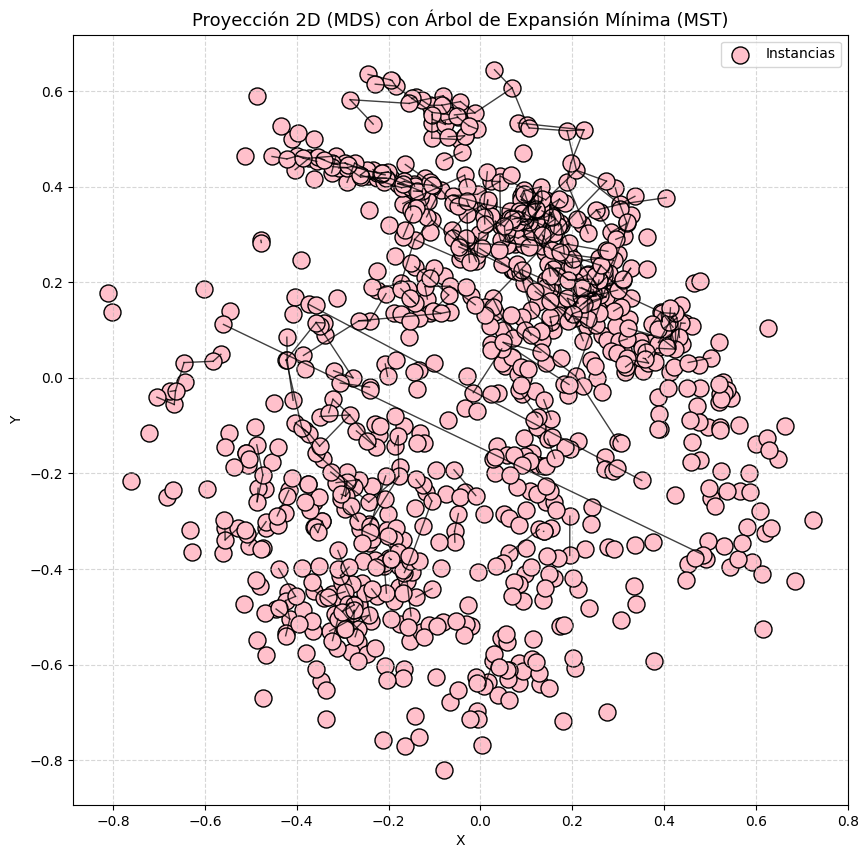

In [ ]:
G, MST, coords = analizar_disimilitud(D)